# **CUSTOMER COHORT ANALYSIS**

## **1. Introduction**
---
This project is part of the **Python for Data Analysis** training program by **MySkill**.

The project uses **Cohort Analysis** to understand customer retention based on their first purchase month. Cohort Analysis is a method that groups customers based on a shared characteristic, in this case, the month of their first purchase, to track their behavior over time.

The analysis also uses **Retention Rate**, which measures the percentage of customers who return to make another purchase after their first purchase. A higher retention rate indicates that more customers continue to purchase over time.

The analysis covers data cleaning, EDA, cohort formation, and retention analysis to identify customer retention patterns over time.


## **2. Dataset Explanation**

---
The dataset used in this analysis was provided by **MySkill** under the name *"Retail Online Data"*. It contains more than 460,000 records with 7 features related to customer transactions and product purchases.

The features are described as follows:

| Feature        | Description                              |
| -------------- | ---------------------------------------- |
| `Order ID`     | Unique identifier for each order.        |
| `Product Code` | Unique code assigned to each product.    |
| `Product Name` | Name or description of the product.      |
| `Quantity`     | Number of units purchased in an order.   |
| `Order Date`   | Date and time when the order was placed. |
| `Price`        | Price of the product per unit.           |
| `Customer ID`  | Unique identifier for each customer.     |

These variables provide information about **orders, products, transaction values, and customers**, which are used as the basis for the customer retention analysis.


### **2.1 Import Packages**

The following Python packages are used to support data preparation, analysis, and visualization:


* `Pandas`: Used for data manipulation, data cleaning, and analysis.                                
* `NumPy` : Used for numerical operations and data processing.                                      
* `Datetime`  : Used to work with date and time data, including date conversion and extraction.         
* `Matplotlib`: Used to create data visualizations and charts.                                          
* `Seaborn` : Used to create statistical visualizations with a more informative and attractive style.



In [ ]:
# pip install pandas
# pip install numpy
# pip install datetime
# pip install matplotlib
# pip install seaborn
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Integration with google drive folder
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir()

['.config', 'drive', 'sample_data']

### **2.2 Import Dataset from CSV to Data Frame**

In [ ]:
# Import Dataset
df = pd.read_csv("/content/drive/MyDrive/Dataset Projek/Salinan Online Retail Data.csv", header = 0)
df

,order_id,product_code,product_name,quantity,order_date,price,customer_id
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.85,NaN
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.75,NaN
...,...,...,...,...,...,...,...
461768,539991,21618,4 WILDFLOWER BOTANICAL CANDLES,1,2010-12-23 16:49:00,1.25,NaN
461769,539991,72741,GRAND CHOCOLATECANDLE,4,2010-12-23 16:49:00,1.45,NaN
461770,539992,21470,FLOWER VINE RAFFIA FOOD COVER,1,2010-12-23 17:41:00,3.75,NaN
461771,539992,22258,FELT FARM ANIMAL RABBIT,1,2010-12-23 17:41:00,1.25,NaN


In [ ]:
# Data type information every columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB


## **3. Data Cleaning**
---
Data cleaning is performed to ensure that the dataset is consistent, accurate, and ready for further analysis. The cleaning process consists of **checking missing values, handling incorrect data formats**, and **identifying and handling outliers**.

In [ ]:
# Create a copy dataset
df_clean = df.copy()

# Converting order_date column data type into datetime
df_clean['order_date'] = df_clean['order_date'].astype('datetime64[ns]')

# Create new column named 'Year_Month'
df_clean['Year_Month'] = df_clean['order_date'].dt.to_period('M')

### **3.1 Missing Value**

In [ ]:
# Missing value check
df_clean.isna().sum().sort_values(ascending=False)

,0
customer_id,100920
product_name,2718
product_code,0
order_id,0
quantity,0
order_date,0
price,0
Year_Month,0


In [ ]:
# Handling missing values by deleting them
df_clean = df_clean[~df_clean['customer_id'].isna()]
df_clean = df_clean[~df_clean['product_name'].isna()]

In [ ]:
# Double-check to make sure there are no more missing values
df_clean.isna().sum()

,0
order_id,0
product_code,0
product_name,0
quantity,0
order_date,0
price,0
customer_id,0
Year_Month,0


### **3.2 Handling Incorrect Format**

In [ ]:
# Convert the data in the ‘product_name’ column to all lowercase, with the first letter of each word capitalized
df_clean['product_name'] = df_clean['product_name'].str.title()
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month
0,493410,TEST001,This Is A Test Product.,5,2010-01-04 09:24:00,4.50,12346.0,2010-01
1,C493411,21539,Retro Spots Butter Dish,-1,2010-01-04 09:43:00,4.25,14590.0,2010-01
2,493412,TEST001,This Is A Test Product.,5,2010-01-04 09:53:00,4.50,12346.0,2010-01
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01
...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12


In [ ]:
# Drop 'product_code' & 'product_name' is conduct 'Test' word
df_clean = df_clean[(~df_clean['product_name'].str.contains('Test')) |
                    (~df_clean['product_code'].str.title().str.contains('Test'))]
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month
1,C493411,21539,Retro Spots Butter Dish,-1,2010-01-04 09:43:00,4.25,14590.0,2010-01
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01
...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12


In [ ]:
# Create a new “status” column containing “cancelled” if “order_id” begins with the letter “C”, and ‘delivered’ if it does not begin with the letter “C".
df_clean['status'] = np.where(df_clean['order_id'].str[:1] == 'C', 'cancelled', 'delivered')
df_clean

/tmp/ipykernel_499/2057620984.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['status'] = np.where(df_clean['order_id'].str[:1] == 'C', 'cancelled', 'delivered')


,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status
1,C493411,21539,Retro Spots Butter Dish,-1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
...,...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered


In [ ]:
# Change the negative numbers in the “quantity” column to positive, because negative numbers only indicate a “canceled” status
df_clean['quantity'] = df_clean['quantity'].abs()
df_clean

/tmp/ipykernel_499/3915412101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['quantity'] = df_clean['quantity'].abs()


,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status
1,C493411,21539,Retro Spots Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
...,...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered


In [ ]:
# Delete rows with a negative ‘price’ value
df_clean = df_clean[df_clean['price']>0]
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status
1,C493411,21539,Retro Spots Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
...,...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered


In [ ]:
# Create an “amount” column, which is the product of ‘quantity’ and “price”
df_clean ['amount'] = df_clean['quantity']*df_clean['price']
df_clean

/tmp/ipykernel_499/4246801835.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean ['amount'] = df_clean['quantity']*df_clean['price']


,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status,amount
1,C493411,21539,Retro Spots Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled,4.25
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,91.80
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,51.00
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,5.10
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,8.50
...,...,...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered,1.25
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered,9.90


### **3.3 Replace the `product_name` for each `product_code` that has multiple `product_name` entries with the one that appears most frequently**

In [ ]:
# Counting the Number of Orders Based on Unique ‘product_code’ and ‘product_name’ Values
most_freq_product_name = df_clean.groupby(['product_code', 'product_name'], as_index=False).agg(order_cnt = ('order_id', 'nunique')).sort_values(['product_code','order_cnt'], ascending=[True, False])
most_freq_product_name

,product_code,product_name,order_cnt
0,10002,Inflatable Political Globe,204
1,10080,Groovy Cactus Inflatable,3
2,10120,Doggy Rubber,31
3,10123C,Hearts Wrapping Tape,32
4,10123G,Army Camo Wrapping Tape,11
...,...,...,...
4304,D,Discount,78
4305,M,Manual,482
4306,PADS,Pads To Match All Cushions,14
4307,POST,Postage,57


In [ ]:
# Rank by order_cnt for each product_code
most_freq_product_name['rank'] = most_freq_product_name.groupby('product_code')['order_cnt'].rank(method='first', ascending=False)
most_freq_product_name

,product_code,product_name,order_cnt,rank
0,10002,Inflatable Political Globe,204,1.0
1,10080,Groovy Cactus Inflatable,3,1.0
2,10120,Doggy Rubber,31,1.0
3,10123C,Hearts Wrapping Tape,32,1.0
4,10123G,Army Camo Wrapping Tape,11,1.0
...,...,...,...,...
4304,D,Discount,78,1.0
4305,M,Manual,482,1.0
4306,PADS,Pads To Match All Cushions,14,1.0
4307,POST,Postage,57,1.0


In [ ]:
# Retrieve only rank = 1 and remove the ‘order_cnt’ and ‘rank’ columns since they are no longer needed
most_freq_product_name = most_freq_product_name[most_freq_product_name['rank']==1].drop(columns=['order_cnt','rank'])
most_freq_product_name

,product_code,product_name
0,10002,Inflatable Political Globe
1,10080,Groovy Cactus Inflatable
2,10120,Doggy Rubber
3,10123C,Hearts Wrapping Tape
4,10123G,Army Camo Wrapping Tape
...,...,...
4304,D,Discount
4305,M,Manual
4306,PADS,Pads To Match All Cushions
4307,POST,Postage


In [ ]:
# Merge 'most_freq_product_name' to df_clean
df_clean = df_clean.merge(most_freq_product_name.rename(columns={'product_name':'most_freq_product_name'}),
                          how='left', on='product_code')
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status,amount,most_freq_product_name
0,C493411,21539,Retro Spots Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled,4.25,Red Retrospot Butter Dish
1,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,91.80,Red Retrospot Mug
2,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,51.00,Retro Spot Large Milk Jug
3,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,5.10,New England Ceramic Cake Server
4,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,8.50,Hand Open Shape Gold
...,...,...,...,...,...,...,...,...,...,...,...
360823,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered,1.25,Set Of 3 Butterfly Cookie Cutters
360824,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69,Hot Baths Soap Holder
360825,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69,Fairy Soap Soap Holder
360826,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered,9.90,Cream Sweetheart Egg Holder


In [ ]:
# Delete the ‘most_freq_product_name’ column so there aren't two columns with the same content
df_clean['product_name'] = df_clean['most_freq_product_name']
df_clean = df_clean.drop(columns='most_freq_product_name')
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status,amount
0,C493411,21539,Red Retrospot Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled,4.25
1,493414,21844,Red Retrospot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,91.80
2,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,51.00
3,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,5.10
4,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,8.50
...,...,...,...,...,...,...,...,...,...,...
360823,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered,1.25
360824,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69
360825,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69
360826,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered,9.90


In [ ]:
# Change the format of the ‘customer_id’ column to the string data type
df_clean['customer_id'] = df_clean['customer_id'].astype(str)

### **3.4 Handling Outliers**

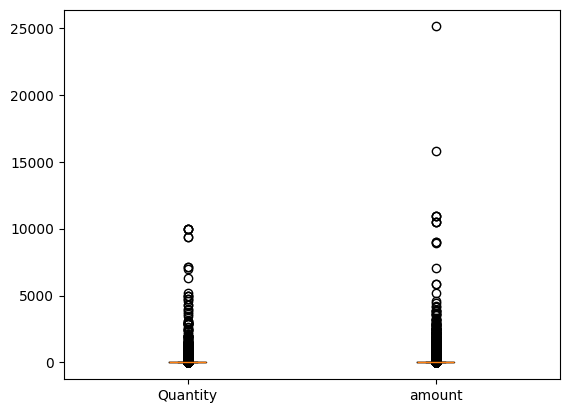

In [ ]:
# Outliers check through the boxplot
plt.boxplot([
    df_clean['quantity'],
    df_clean['amount']])

plt.xticks([1, 2], ['Quantity', 'amount'])
plt.show()

> Several outliers were identified through the boxplot analysis. These outliers were handled using the **Z-score method**. Observations with an absolute Z-score greater than 3 were considered extreme values and removed from the dataset. After removing the outliers, the dataset was expected to have a more consistent distribution, reducing the potential influence of extreme values on the subsequent analysis.



In [ ]:
# Dropping Outliers based on zscore
from scipy import stats
df_clean = df_clean[(np.abs(stats.zscore(df_clean[['quantity','amount']]))<3).all(axis=1)]
df_clean = df_clean.reset_index(drop=True)

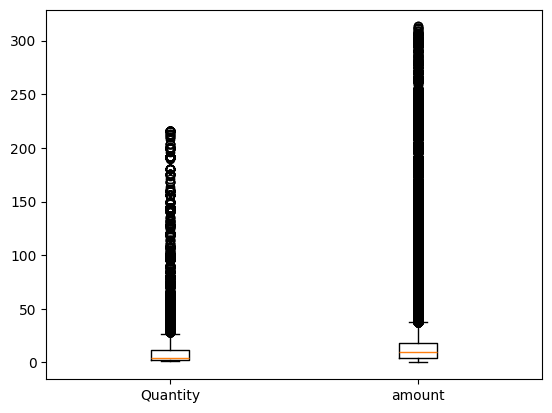

In [ ]:
# Outliers recheck
plt.boxplot([
    df_clean['quantity'],
    df_clean['amount']])

plt.xticks([1, 2], ['Quantity', 'amount'])
plt.show()

In [ ]:
# Check the data type after the fix
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358469 entries, 0 to 358468
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      358469 non-null  object        
 1   product_code  358469 non-null  object        
 2   product_name  358469 non-null  object        
 3   quantity      358469 non-null  int64         
 4   order_date    358469 non-null  datetime64[ns]
 5   price         358469 non-null  float64       
 6   customer_id   358469 non-null  object        
 7   Year_Month    358469 non-null  period[M]     
 8   status        358469 non-null  object        
 9   amount        358469 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5), period[M](1)
memory usage: 27.3+ MB


> The dataset already has the appropriate data types for each column: one `datetime` data type, two `float` data types, one `integer` data type, five `string` data types, and one `period` data type. In addition, the data no longer contains any missing values or outliers, so it can be said that the dataset is clean and ready for use in **cohort analysis**.

## **4. Exploratory Data Analysis (EDA)**

---

Exploratory Data Analysis (EDA) is performed to understand the main characteristics and patterns in the transaction data before conducting the Cohort Analysis.

### **4.1 Descriptive Statistics**
Descriptive statistics are used to summarize the characteristics of the numerical features in the dataset, including `quantity`, `price`, and `amount`. In addition, a dataset overview is provided for categorical features.

In [ ]:
# Numerical Descriptive Statistics
df_clean[['quantity', 'price', 'amount']].describe()

,quantity,price,amount
count,358469.000000,358469.000000,358469.000000
mean,9.362754,3.087634,16.757486
std,16.288556,5.502037,25.312974
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.200000
50%,4.000000,1.950000,10.200000
75%,12.000000,3.750000,17.700000
max,216.000000,311.990000,313.200000


In [ ]:
# Dataset Overview
print("=== DATASET OVERVIEW ===")
print(f"Number of rows         : {df_clean.shape[0]:,}")
print(f"Number of columns      : {df_clean.shape[1]}")
print(f"Number of transactions : {df_clean['order_id'].nunique():,}")
print(f"Number of customers    : {df_clean['customer_id'].nunique():,}")
print(f"Number of products     : {df_clean['product_code'].nunique():,}")
print(f"Transaction period     : {df_clean['order_date'].min().date()} "
      f"until {df_clean['order_date'].max().date()}")

=== DATASET OVERVIEW ===
Number of rows         : 358,469
Number of columns      : 10
Number of transactions : 19,945
Number of customers    : 3,889
Number of products     : 3,891
Transaction period     : 2010-01-04 until 2010-12-23


### **4.2 Transaction Status**

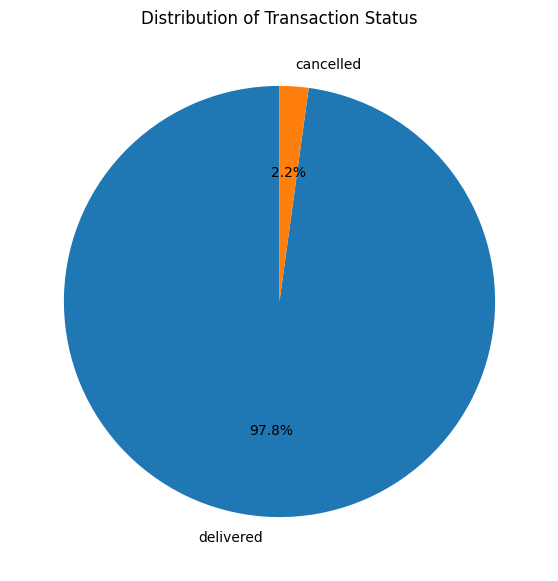

In [ ]:
# Number & percentage of transaction based on status
status_counts = df_clean['status'].value_counts()
status_summary = pd.DataFrame({'Count': df_clean['status'].value_counts(),
                               'Percentage': df_clean['status'].value_counts(normalize=True) * 100})

plt.figure(figsize=(7, 7))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90)

plt.title('Distribution of Transaction Status')
plt.show()

> Based on the pie chart above, the transaction status shows that **97.8% of transactions were successfully processed**, while only **2.2% were canceled**. This indicates that the vast majority of transactions were successfully completed, with a relatively small proportion of orders being canceled.


### **4.3 Top 20 Best Product**

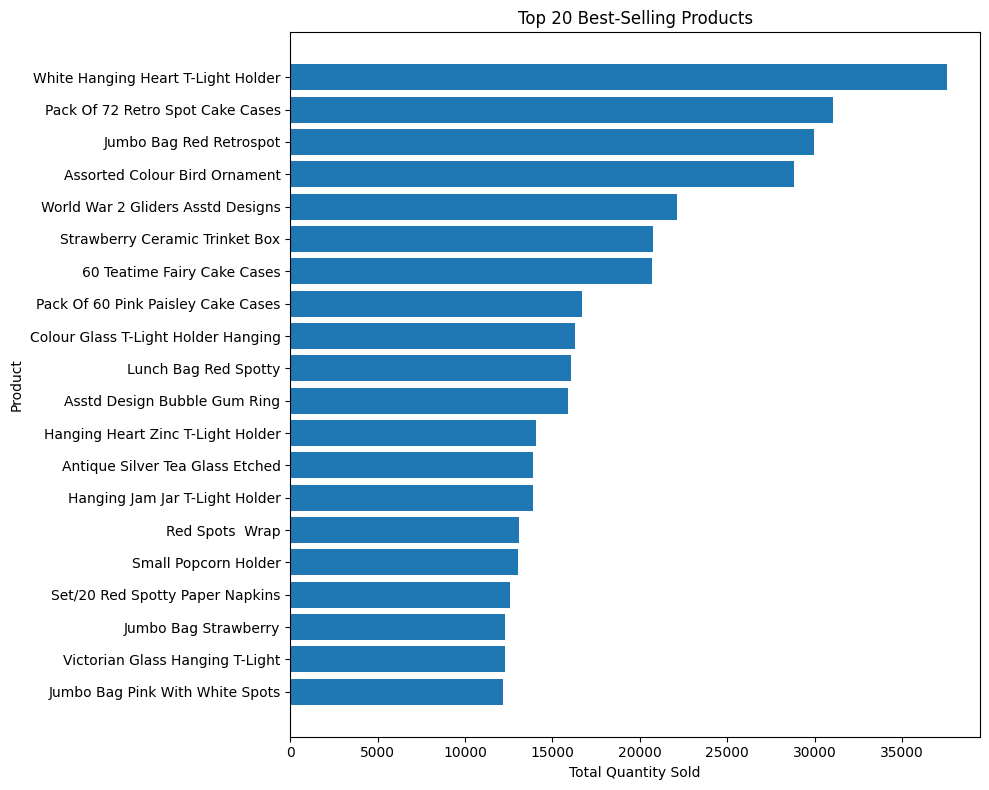

In [ ]:
# Top 20 best-selling products (products with the highest total quantity)
top_20_products = (df_clean.groupby(['product_code', 'product_name'], as_index=False)['quantity'].sum().sort_values('quantity', ascending=False).head(20))

plt.figure(figsize=(10, 8))
plt.barh(top_20_products['product_name'][::-1], top_20_products['quantity'][::-1])

plt.title('Top 20 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

> The bar chart above shows that sales volumes vary across the top 20 best-selling products. **White Hanging Heart T-Light Holder** had the highest total quantity sold, while the remaining products had relatively lower sales volumes. Overall, the results provide an overview of the products with the highest customer demand.

### **4.4 Monthly Transaction Trend**

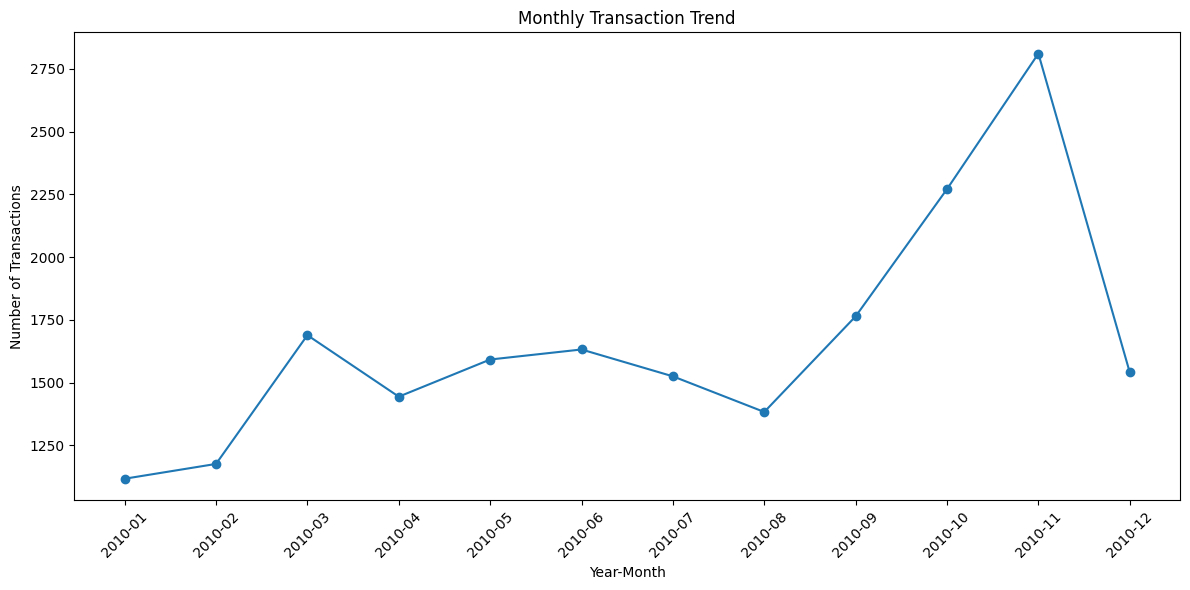

In [ ]:
monthly_transactions = (df_clean.groupby('Year_Month')['order_id'].nunique().reset_index(name='Total Transactions'))

plt.figure(figsize=(12, 6))
plt.plot(monthly_transactions['Year_Month'].astype(str), monthly_transactions['Total Transactions'], marker='o')

plt.title('Monthly Transaction Trend')
plt.xlabel('Year-Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

> The monthly transaction trend shows that the **lowest number of transactions occurred in January**, while the **highest number was recorded in November**. The number of transactions increased significantly from August to November, followed by a sharp decline in December.

## **5. Cohort Analysis**

### **5.1 Create Cohort Column**

In [ ]:
# Perform an aggregation to count the unique ‘order_id's based on the customer ('customer_id’) who made a transaction each month (‘Year_Month’)
df_user_monthly = df_clean.groupby(['customer_id','Year_Month'], as_index=False).agg(order_cnt=('order_id','nunique'))
df_user_monthly

,customer_id,Year_Month,order_cnt
0,12346.0,2010-01,1
1,12346.0,2010-03,1
2,12346.0,2010-06,2
3,12346.0,2010-10,1
4,12608.0,2010-10,1
...,...,...,...
12039,18286.0,2010-06,1
12040,18286.0,2010-08,1
12041,18287.0,2010-05,1
12042,18287.0,2010-09,2


In [ ]:
# Determine and create a cohort column (the month in which the customer made their first transaction) for each customer
df_user_monthly['cohort'] = df_user_monthly.groupby('customer_id')['Year_Month'].transform('min')
df_user_monthly

,customer_id,Year_Month,order_cnt,cohort
0,12346.0,2010-01,1,2010-01
1,12346.0,2010-03,1,2010-01
2,12346.0,2010-06,2,2010-01
3,12346.0,2010-10,1,2010-01
4,12608.0,2010-10,1,2010-10
...,...,...,...,...
12039,18286.0,2010-06,1,2010-06
12040,18286.0,2010-08,1,2010-06
12041,18287.0,2010-05,1,2010-05
12042,18287.0,2010-09,2,2010-05


In [ ]:
# Calculate the number of months since the transaction using the “cohort” column and add 1 to it so that 0 months becomes 1, which indicates the first transaction
from operator import attrgetter
df_user_monthly['period_num'] = (df_user_monthly['Year_Month'] - df_user_monthly['cohort']).apply(attrgetter('n')) + 1
df_user_monthly

,customer_id,Year_Month,order_cnt,cohort,period_num
0,12346.0,2010-01,1,2010-01,1
1,12346.0,2010-03,1,2010-01,3
2,12346.0,2010-06,2,2010-01,6
3,12346.0,2010-10,1,2010-01,10
4,12608.0,2010-10,1,2010-10,1
...,...,...,...,...,...
12039,18286.0,2010-06,1,2010-06,1
12040,18286.0,2010-08,1,2010-06,3
12041,18287.0,2010-05,1,2010-05,1
12042,18287.0,2010-09,2,2010-05,5


### **5.2 Cohort Pivot Table**

In [ ]:
# Create a pivot table with index = ‘cohort’, columns = ‘period_num’, and values = 'customer_id'
df_user_monthly_pivot = df_user_monthly.pivot_table(index='cohort', columns='period_num', values='customer_id', aggfunc='nunique')
df_user_monthly_pivot

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,713.0,280.0,334.0,313.0,305.0,304.0,293.0,268.0,285.0,319.0,335.0,249.0
2010-02,461.0,154.0,128.0,161.0,152.0,121.0,119.0,159.0,153.0,166.0,100.0,NaN
2010-03,528.0,146.0,158.0,145.0,140.0,123.0,149.0,186.0,193.0,96.0,NaN,NaN
2010-04,326.0,82.0,75.0,63.0,69.0,79.0,98.0,101.0,50.0,NaN,NaN,NaN
2010-05,274.0,55.0,50.0,52.0,52.0,72.0,67.0,43.0,NaN,NaN,NaN,NaN
2010-06,266.0,53.0,56.0,60.0,65.0,85.0,39.0,NaN,NaN,NaN,NaN,NaN
2010-07,179.0,38.0,37.0,52.0,53.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,160.0,35.0,50.0,48.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,227.0,64.0,60.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **5.3 Cohort Size**

In [ ]:
# Retrieve the first column (the number of customers making their first transaction)
cohort_size = df_user_monthly_pivot.iloc[:, 0]
cohort_size

,1
cohort,
2010-01,713.0
2010-02,461.0
2010-03,528.0
2010-04,326.0
2010-05,274.0
2010-06,266.0
2010-07,179.0
2010-08,160.0
2010-09,227.0


### **5.4 Retention Rate**

In [ ]:
# Divide the first column (“cohort_size”) by all the values in the pivot table to calculate the retention rate
df_retention_cohort = df_user_monthly_pivot.divide(cohort_size, axis=0)
df_retention_cohort

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,1.0,0.392707,0.468443,0.438990,0.427770,0.426367,0.410940,0.375877,0.399719,0.447405,0.469846,0.349229
2010-02,1.0,0.334056,0.277657,0.349241,0.329718,0.262473,0.258134,0.344902,0.331887,0.360087,0.216920,NaN
2010-03,1.0,0.276515,0.299242,0.274621,0.265152,0.232955,0.282197,0.352273,0.365530,0.181818,NaN,NaN
2010-04,1.0,0.251534,0.230061,0.193252,0.211656,0.242331,0.300613,0.309816,0.153374,NaN,NaN,NaN
2010-05,1.0,0.200730,0.182482,0.189781,0.189781,0.262774,0.244526,0.156934,NaN,NaN,NaN,NaN
2010-06,1.0,0.199248,0.210526,0.225564,0.244361,0.319549,0.146617,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.212291,0.206704,0.290503,0.296089,0.167598,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.218750,0.312500,0.300000,0.168750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,1.0,0.281938,0.264317,0.136564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **5.5 Create User Retention Cohort Heatmap**

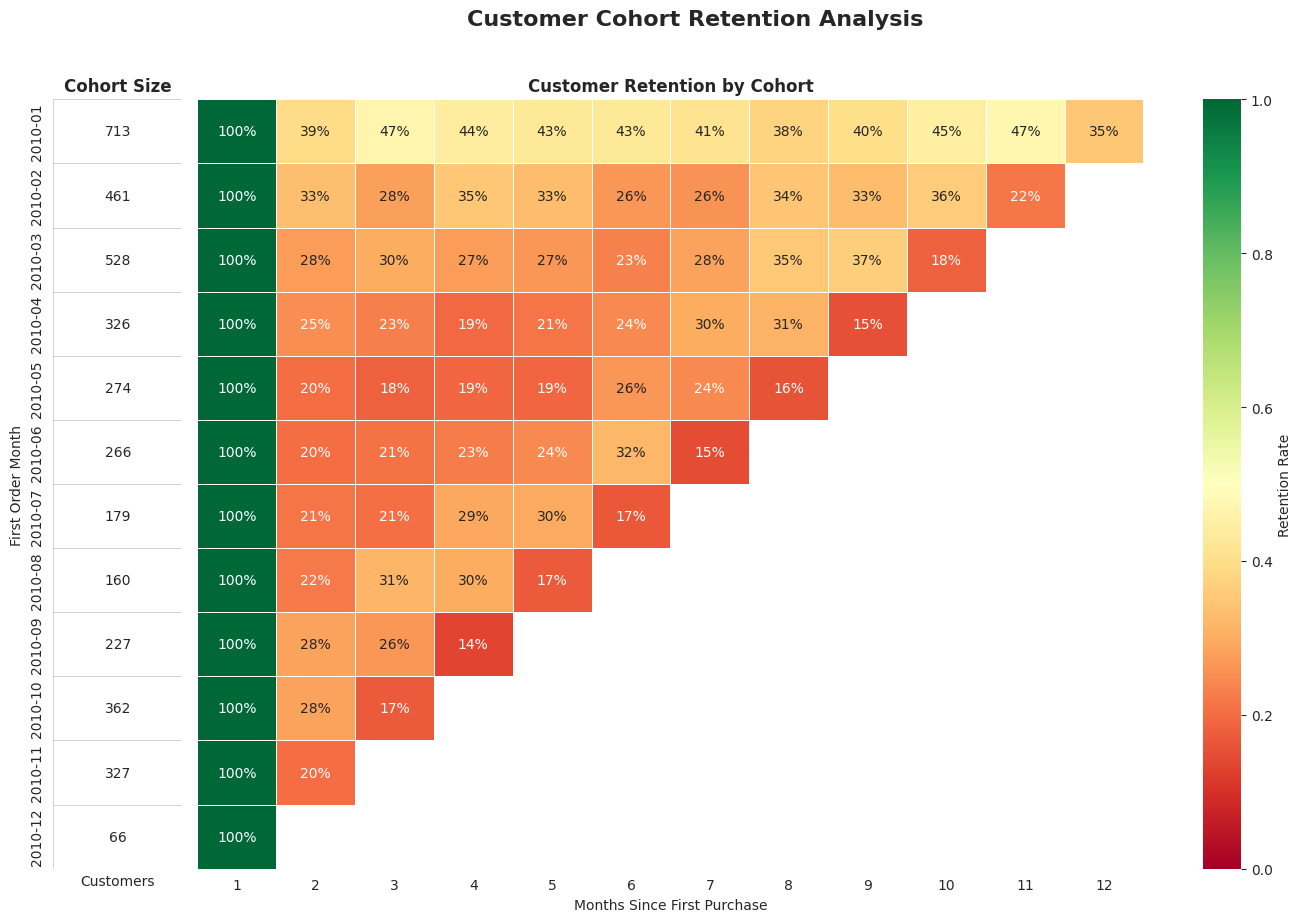

In [ ]:
import matplotlib.colors as mcolors

with sns.axes_style('white'):

    fig, ax = plt.subplots(
        1, 2,
        figsize=(14, 9),
        sharey=True,
        gridspec_kw={'width_ratios': [1.2, 11]}
    )

    # Cohort Size
    df_cohort_size = pd.DataFrame(cohort_size)

    white_cmap = mcolors.ListedColormap(['white'])

    sns.heatmap(
        df_cohort_size,
        annot=True,
        fmt=',.0f',
        cmap=white_cmap,
        cbar=False,
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax[0]
    )

    ax[0].set_title(
        'Cohort Size',
        fontsize=12,
        fontweight='bold'
    )

    ax[0].set(
        xlabel='Customers',
        ylabel='First Order Month'
    )

    ax[0].tick_params(
        bottom=False,
        labelbottom=False
    )


    # Retention Rate
    sns.heatmap(
        df_retention_cohort,
        annot=True,
        fmt='.0%',
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={
            'label': 'Retention Rate'
        },
        ax=ax[1]
    )

    ax[1].set_title(
        'Customer Retention by Cohort',
        fontsize=12,
        fontweight='bold'
    )

    ax[1].set(
        xlabel='Months Since First Purchase',
        ylabel=''
    )

    # Main title
    fig.suptitle(
        'Customer Cohort Retention Analysis',
        fontsize=16,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()

#### **Heatmap Interpretation**

Based on the cohort analysis heatmap above, the following information can be derived.

* January had the largest customer cohort, with 713 customers making
their first purchase. This cohort also recorded the highest retention in the second month at 39% compared to other cohorts.
* The January cohort showed relatively strong retention in the following months, with retention rates remaining around 40% or higher, indicating higher customer loyalty.
* Overall, customer retention was relatively low, as retention rates for most cohorts and periods remained below 50%.
* December recorded the lowest retention rates across all cohorts, indicating a notable decline in customer retention toward the end of the observation period.

## **6. Insights & Recommendations**


---
Based on the EDA and Cohort Analysis, several key findings were identified regarding customer retention and purchasing behavior. These findings provide a basis for recommendations that can help improve customer retention and support better business decisions.

### **Insights**

1.   Most cohorts have retention rates below 50%, indicating that a large proportion of customers do not return after their initial purchase.
2.   The January cohort had the largest customer base with 713 customers and showed relatively strong retention compared to other cohorts.
3.   Retention rates dropped noticeably in December across all cohorts, making it the weakest retention period in the analysis.
4.   A small number of products accounted for a relatively high share of total units sold, indicating stronger customer demand for specific products.

### **Recommendations**


1.   Implement targeted retention strategies, such as offers tailored to customer needs, follow-up campaigns, and loyalty programs to encourage repeat purchases.
2.   Analyze the purchasing behavior and characteristics of the January cohort to identify patterns that can be applied to other customer cohorts.
3.   Evaluate customer engagement and purchasing patterns before December and consider targeted campaigns to maintain customer activity during this period.
4.   Prioritize high-demand products in inventory planning and use them as opportunities for cross-selling or product bundling to increase customer purchases.


